In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
    
import numpy as np
import scipy
from scipy.sparse import coo_matrix, csr_matrix, csc_matrix, block_diag, identity, hstack
import matplotlib.pyplot as plt
from pyiga import assemble, bspline, vform, geometry,vis, solvers, utils, topology, algebra, quadrature, operators
#from sksparse.cholmod import cholesky
from pyiga import adaptive as adap
import itertools
import time
import statistics as st
from pyiga import algebra_cy, assemble_cy, bspline_cy

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)
np.set_printoptions(formatter={'float_kind':"{:.3f}".format})

In [8]:
kv = 2*(bspline.make_knots(2,0,1,3),)

In [9]:
geo1 = geometry.unit_square()
geo2=geo1.translate((1,0))

In [20]:
M = topology.MultiPatch([(kv,geo1),(kv,geo2)])

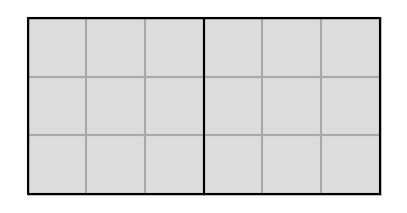

In [21]:
M.plotmesh(knots=1, color='gainsboro')
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Squares.pdf',bbox_inches='tight');

In [22]:
M.split_patch(1)

(1, 2, 3, 4)

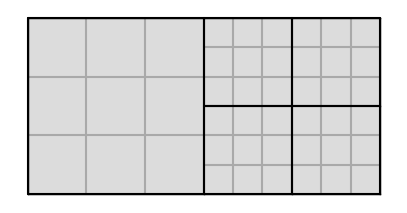

In [23]:
M.plotmesh(knots=1, color='gainsboro')
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/SquaresSplit.pdf',bbox_inches='tight');

In [24]:
M.split_patch(0)

(0, 5, 6, 7)

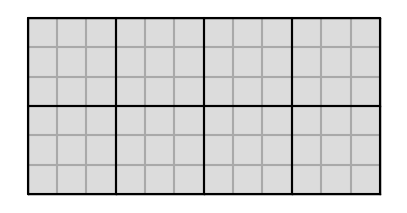

In [25]:
M.plotmesh(knots=1, color='gainsboro')
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/SquaresRefined.pdf',bbox_inches='tight');

In [23]:
from sksparse.cholmod import cho_factor
import scipy.sparse as sp
import numpy as np

A = sp.eye(5, format="csc")
factor = cho_factor(A)
x = factor.solve(np.ones(5))
print(x)

[1. 1. 1. 1. 1.]


In [2]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [3]:
factor

(<Compressed Sparse Row sparse array of dtype 'float64'
 	with 5 stored elements and shape (5, 5)>,
 array([0, 1, 2, 3, 4], dtype=int32))

In [6]:
cholesky(A)[0].toarray()

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [9]:
factor = cholesky(A)

In [10]:
factor

(<Compressed Sparse Row sparse array of dtype 'float64'
 	with 5 stored elements and shape (5, 5)>,
 array([0, 1, 2, 3, 4], dtype=int32))

In [11]:
import sksparse
import sksparse.cholmod as cholmod

print(sksparse.__version__)
print(cholmod.cholesky)

0.5.0
<cyfunction cholesky at 0x7f4de59d8ef0>


In [18]:
from sksparse.cholmod import cholesky
import scipy.sparse as sp
import numpy as np

A = sp.eye(3, format="csc")

factor = sksparse.cholmod.cho_factor(A)

print(type(factor))
print(repr(factor))
print(isinstance(factor, tuple))

<class 'sksparse.cholmod.CholeskyFactor'>
CholeskyFactor(N=3, nnz=3, is_ll=True, is_super=False, itype=np.int32, dtype=np.float64, order=amd)
False


In [14]:
sksparse.cholmod.cholesky(A)

(<Compressed Sparse Row sparse array of dtype 'float64'
 	with 3 stored elements and shape (3, 3)>,
 array([0, 1, 2], dtype=int32))

In [17]:
sksparse.cholmod.cho_factor

<cyfunction cho_factor at 0x7f4de5983ba0>

In [16]:
help(cholmod.cholesky)

Help on cython_function_or_method in module sksparse.cholmod:

cholesky(A, beta=0.0, *, lower=False, order='default', sym_kind=None, supernodal_mode=None)
    Compute the Cholesky factorization of a sparse matrix.

    This function computes the Cholesky factorization of a symmetric positive
    definite matrix `A`:

    .. math::

        R^{\top} R = P A P^{\top},

    where `R` is an upper triangular matrix. Only the upper triangular part of
    `A` is used. If ``lower`` is True, the lower triangular factor `L` is
    returned instead, such that:

    .. math::

        L L^{\top} = P A P^{\top}.

    In this case, only the lower triangular part of `A` is used.

    If ``beta`` is a scalar value, compute the factorization of:

    .. math::

        P A P^{\top} + \beta I,

    where `I` is the identity matrix.

    Parameters
    ----------
    A : (N, N) {array_like, sparse array}
        An array convertible to a sparse matrix in Compressed Sparse Column
        (CSC) format. The